
<img src="nlp.png" width="1700" height="300" />




# **NLP Assignment 1: Language Modeling for Urdu News Articles**

Date of Submission:15 February



In [ ]:
import requests
from bs4 import BeautifulSoup
import json
import re
import time
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import pandas as pd

## **Part 1: BBC Urdu Dataset Collection and Preprocessing**
In this part, BBC Urdu news articles are collected and prepared into a clean dataset using normalization and custom preprocessing tools. The output of this part will be reused directly in Part 2.

News articles must be scraped from:
https://www.bbc.com/urdu

Students must scrape:
- Minimum: 200 articles
- Maximum: 300 articles

Each article must be complete and properly structured.

Article metadata must be stored in a JSON file with the following constraints:
- Each article must be numbered
- Article numbers must be unique
- Article numbers must match TXT files
- Article body must not be included

### ***Format Example***
```json
{
  "1": {
    "title": "پاکستان میں مہنگائی کی شرح میں اضافہ",
    "publish_date": "2024-01-15"
  },
  "2": {
    "title": "کراچی میں بارش کے بعد صورتحال",
    "publish_date": "2024-02-02"
  }
}

### ***raw.txt File***
This file must contain:
- Raw scraped article content
- No cleaning or normalization
- One article per block
- Each article must start with its article number

### ***Example***
```json
[1]
یہ خبر بی بی سی اردو سے حاصل کی گئی ہے...

[2]
کراچی میں بارش کے بعد صورتحال خراب ہو گئی...

## 1. Dataset Collection & Metadata Management (6 Marks)
-> Scraping 200–300 complete BBC Urdu articles (2 Marks)



-> Correct JSON metadata structure with unique numbering and no article body (2 Marks)


-> Consistency between JSON, raw.txt, and cleaned.txt numbering (2 Marks)

## 2. Raw Data File (raw.txt) Compliance (4 Marks)

-> All article bodies included without any preprocessing (2 Marks)
-> Correct formatting with one article per block and proper numbering (2 Marks)

In [ ]:


BASE_URL = "https://www.bbc.com"
START_PAGES = [
    "https://www.bbc.com/urdu/topics/c340q0p2585t",
    "https://www.bbc.com/urdu/topics/c340q0p2585t?page=2",
    "https://www.bbc.com/urdu/topics/c340q0p2585t?page=3",
    "https://www.bbc.com/urdu/topics/c340q0p2585t?page=4",
    "https://www.bbc.com/urdu/topics/c340q0p2585t?page=5",
    "https://www.bbc.com/urdu/topics/c340q0p2585t?page=6",
    "https://www.bbc.com/urdu/topics/c340q0p2585t?page=7",
    "https://www.bbc.com/urdu/topics/c340q0p2585t?page=8",
    "https://www.bbc.com/urdu/topics/c340q0p2585t?page=9",
    "https://www.bbc.com/urdu/topics/c340q0p2585t?page=10",
    "https://www.bbc.com/urdu/topics/c340q0p2585t?page=11",
    "https://www.bbc.com/urdu/topics/c340q0p2585t?page=12",
    "https://www.bbc.com/urdu/topics/c340q0p2585t?page=13"
]
MAX_ARTICLES = 300

headers = {
    "User-Agent": "Mozilla/5.0"
}

article_links = []
visited = set()
articles_meta = {}
raw_blocks = []

# -----------------------
# STEP 1: Collect links
# -----------------------
def collect_links():
    for page in START_PAGES:
        r = requests.get(page, headers=headers)
        soup = BeautifulSoup(r.text, "html.parser")

        for a in soup.find_all("a", href=True):
            href = a["href"]

            if "/urdu/articles/" in href:
                full_url = href if href.startswith("http") else BASE_URL + href

                if full_url not in visited:
                    visited.add(full_url)
                    article_links.append(full_url)

            if len(article_links) >= MAX_ARTICLES:
                break

        if len(article_links) >= MAX_ARTICLES:
            break

    print("Collected links:", len(article_links))

# -----------------------
# STEP 2: Scrape articles
# -----------------------
def scrape_articles():
    article_id = 1

    for url in article_links:
        try:
            r = requests.get(url, headers=headers, timeout=10)
            soup = BeautifulSoup(r.text, "html.parser")

            # Headline
            headline_div = soup.find("div", class_="css-8aggre")
            if not headline_div:
                continue
            title = headline_div.get_text(strip=True)

            # Publish date
            time_tag = soup.find("time")
            publish_date = time_tag["datetime"][:10] if time_tag else "unknown"

            # Body paragraphs
            body_divs = soup.find_all("div", class_="css-ffsn56")

            body_text = ""
            for div in body_divs:
                body_text += div.get_text(strip=True) + "\n"

            # if len(body_text) < 100:
            #     continue

            # JSON metadata
            articles_meta[str(article_id)] = {
                "title": title,
                "publish_date": publish_date
            }

            # Raw file block
            raw_blocks.append(f"[{article_id}]\n{body_text}\n")

            print(f"Scraped article {article_id}")
            article_id += 1

            if article_id > MAX_ARTICLES:
                break

            time.sleep(0.4)

        except Exception:
            print("Skipped (short):", url)

            continue

# -----------------------
# STEP 3: Write files
# -----------------------
def write_files():
    with open("articles.json", "w", encoding="utf-8") as f:
        json.dump(articles_meta, f, ensure_ascii=False, indent=2)

    with open("raw.txt", "w", encoding="utf-8") as f:
        for block in raw_blocks:
            f.write(block)

# -----------------------
# RUN
# -----------------------
collect_links()
scrape_articles()
write_files()



## ***cleaned.txt File***

This file must contain:
- Fully preprocessed data
- Normalized Urdu text
- Noise removed
- Sentence segmented
- Ready for language model training
- Article numbering matching raw.txt and JSON

**Refer to the given Assignment PDF Document for the data cleaning and normalizing techniques**

## 3. Data Cleaning & Normalization (10 Marks)

Diacritics removal correctly implemented (2 Marks)

In [7]:

diatrics_pattern = re.compile(
    r'[\u064B-\u065F\u0670\u06D6-\u06ED]'
)

def remove_diacritics(text: str) -> str:
    return re.sub(diatrics_pattern, '', text)


Noise removal including URLs, emojis, and web artifacts (2 Marks)

In [8]:
url_pattern = re.compile(r'https?://\S+|www\.\S+')
emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF"
    "]+",
    flags=re.UNICODE
)

def remove_web_noise(text: str) -> str:
    text = re.sub(url_pattern, '', text)
    text = re.sub(emoji_pattern, '', text)
    return text


Removal of non-Urdu, Roman Urdu, and English text (2 Marks)

In [9]:
def keep_only_urdu(text: str) -> str:
    return ''.join(
        ch for ch in text
        if (
            '\u0600' <= ch <= '\u06FF' or  # Arabic / Urdu
            '\u0750' <= ch <= '\u077F' or
            ch in ' ۔،؟!\n'
        )
    )


Sentence segmentation using Urdu punctuation (2 Marks)

In [10]:
sentence_split_patt = re.compile(r'([۔?!])')

def sentence_segment(text: str):
    parts = re.split(sentence_split_patt, text)
    sentences = []

    for i in range(0, len(parts)-1, 2):
        sentence = parts[i].strip() + parts[i+1]
        if sentence.strip():
            sentences.append(sentence.strip())

    return sentences


Whitespace and formatting normalization (2 Marks)

In [11]:
def normalize_whitespace(text: str) -> str:
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


Replace numbers with NUM

In [12]:
# replace numbers with a placeholder
def replace_numbers(text: str) -> str:
    return re.sub(r'\d+', ' <NUM> ', text)  

Make cleaned file

In [13]:
def clean_article_text(text: str) -> str:
    text = remove_diacritics(text)
    text = remove_web_noise(text)
    text = keep_only_urdu(text)
    text = replace_numbers(text)
    text = normalize_whitespace(text)

    sentences = sentence_segment(text)
    return '\n'.join(sentences)


In [14]:
ARTICLE_SPLIT_PATTERN = re.compile(r'(\[\d+\])')

### Make Cleaned.txt

In [15]:
def process_raw_file(raw_path="raw.txt", cleaned_path="cleaned.txt"):
    with open(raw_path, "r", encoding="utf-8") as f:
        content = f.read()

    parts = re.split(ARTICLE_SPLIT_PATTERN, content)

    cleaned_blocks = []

    i = 1
    while i < len(parts):
        article_id = parts[i].strip()        # [1]
        article_text = parts[i + 1].strip()  # body text

        cleaned_text = clean_article_text(article_text)

        cleaned_blocks.append(article_id)
        cleaned_blocks.append(cleaned_text + "\n\n")

        i += 2

    with open(cleaned_path, "w", encoding="utf-8") as f:
        f.write('\n'.join(cleaned_blocks))


In [16]:
process_raw_file()


## ***Custom Urdu Tokenizer***

The tokenizer must handle:
- Word boundaries
- Punctuation
- Postpositions
- Numbers and special tokens

All numbers must be replaced with `<NUM>`.

Input:

پاکستان میں میں بارش ہوئی  
2024  

Output:

پاکستان | میں | میں | بارش | ہوئی  
`<NUM>`

Custom Urdu tokenizer including word boundaries, punctuation, and <NUM> handling
(4 Marks)

In [17]:
# Your code here, Implement custom Urdu Tokenizer
punctuation_marks = '۔،؟!'

def urdu_tokenizer(text):
    tokens = []
    current = ''

    for ch in text:
        if ch in punctuation_marks:
            if current:
                tokens.append(current)
                current = ''
            tokens.append(ch)
        elif ch.isspace():
            if current:
                tokens.append(current)
                current = ''
        else:
            current += ch

    if current:
        tokens.append(current)

    return tokens


## ***Custom Urdu Stemmer***
The stemmer must remove common Urdu suffixes.

Input:
لڑکیوں نے کتابیں پڑھیں  

Output:
لڑکی | کتاب | پڑھ

Custom Urdu stemmer with correct suffix handling (3 Marks)


In [18]:
# Your code here, Implement custom Urdu Stemmer
common_suffixes = [
    'یاں', 'وں', 'یں', 'ات', 'گی', 'گا', 'نے', 'کو', 'سے', 'پر'
]

def urdu_stemmer(word):
    for suf in common_suffixes:
        if word.endswith(suf) and len(word) > len(suf) + 2:
            return word[:-len(suf)]
    return word


In [19]:
def stem_tokens(tokens):
    return [urdu_stemmer(token) for token in tokens]


## ***Custom Urdu Lemmatizer***

The lemmatizer is restricted to:
- Plural normalization
- Gender normalization

Plural:
- لڑکیاں -> لڑکی  
- کتابوں -> کتاب  

Gender:
- اچھی -> اچھا  
- بڑی -> بڑا

Custom Urdu lemmatizer for plural and gender normalization (3 Marks)

In [20]:
# Your code here, Implement custom Urdu Lemmatizer
lemma_mapping ={
    'لڑکیاں': 'لڑکی',
    'لڑکے': 'لڑکا',
    'عورتیں': 'عورت',
    'مردوں': 'مرد',
    'بچوں': 'بچہ',
    'لوگوں': 'لوگ',
    'کتابیں': 'کتاب',
    'کرسیاں': 'کرسی',
    'آنکھوں': 'آنکھ',
    'ہاتھوں': 'ہاتھ',
    'باتیں': 'بات',
    'راتوں': 'رات',
    'دروازوں': 'دروازہ',
    'گھروں': 'گھر',
    'شہروں': 'شہر',
    'کھاتا': 'کھا',
    'کھاتی': 'کھا',
    'کھاتے': 'کھا',
    'پیتا': 'پی',
    'پیتے': 'پی',
    'سوتا': 'سو',
    'سوتے': 'سو',
    'کرتا': 'کر',
    'کرتی': 'کر',
    'کرتے': 'کر',
    'ہوا': 'ہو',
    'ہوئی': 'ہو',
    'ہوئے': 'ہو',
    'گیا': 'جا',
    'گئی': 'جا',
    'گئے': 'جا',
    'آیا': 'آ',
    'آئی': 'آ',
    'آئے': 'آ',
    'اچھے': 'اچھا',
    'اچھی': 'اچھا',
    'بڑے': 'بڑا',
    'بڑی': 'بڑا',
    'چھوٹے': 'چھوٹا',
    'چھوٹی': 'چھوٹا',
    'لمبے': 'لمبا',
    'لمبی': 'لمبا'

}

In [21]:
def urdu_lemmatizer(word):
    return lemma_mapping .get(word, word)


In [22]:
def lemmatize_tokens(tokens):
    return [urdu_lemmatizer(token) for token in tokens]


In [23]:

ARTICLE_SPLIT_PATTERN = r'(\[\d+\])'

def load_articles(path="cleaned.txt"):
    with open(path, "r", encoding="utf-8") as f:
        content = f.read()

    parts = re.split(ARTICLE_SPLIT_PATTERN, content)

    articles = []
    i = 1
    while i < len(parts):
        article_id = parts[i].strip()
        text = parts[i + 1].strip()
        articles.append((article_id, text))
        i += 2

    return articles


In [24]:
def build_dataframe(articles):
    data = []

    for article_id, text in articles:
        tokens = urdu_tokenizer(text)
        stems = stem_tokens(tokens)
        lemmas = lemmatize_tokens(tokens)

        data.append({
            "article_id": article_id,
            "original_text": text,
            "tokens": tokens,
            "stems": stems,
            "lemmas": lemmas
        })

    df = pd.DataFrame(data)
    return df


In [25]:
def save_dataset(lines, path):
    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))


In [26]:
articles = load_articles("cleaned.txt")
df = build_dataframe(articles)
print(len(df))

307


### ***Mandatory Deliverables for Part 1***
- JSON metadata file
- raw.txt
- cleaned.txt
- Tokenized dataset
- Stemmed dataset
- Lemmatized dataset


In [ ]:

#print some part of raw.txt
with open("raw.txt", "r", encoding="utf-8") as f:
    raw_sample = f.read().split("\n\n")[0]
    print("Sample raw text:", raw_sample[:500], "...")
# print sample of cleaned.txt   
with open("cleaned.txt", "r", encoding="utf-8") as f:
    cleaned_sample = f.read().split("\n\n")[0]
    print("Sample cleaned text:", cleaned_sample[:500], "...")

print("Sample tokens:", df["tokens"].iloc[0])
print("Sample stems:", df["stems"].iloc[0])
print("Sample lemmas:", df["lemmas"].iloc[0])


Sample raw text: [1]
ایک گھنٹہ قبل
’ان بیٹرز کو تو سمجھ ہی نہیں آ رہی۔ اس کو نہیں مار پاؤ گے۔‘
’ان کو کیا، انڈیا کو بھی سمجھ نہیں آئے گی۔‘
’ایسے بولر کے خلاف پریکٹس کے لیے کس کو بلاؤں میں؟‘
’یہ انڈیا کے خلاف ان کا ٹرمپ کارڈ ہو گا۔‘
یہ وہ چند جملے ہیں جو ایک انڈین چینل پر پاکستان اور امریکہ کی ٹیم کے درمیان ہونے والے میچ کی کمٹری کے دوران ادا کیے گئے اور ان جملوں میں ذکر ہو رہا ہے پاکستانی بولر عثمان طارق کا جن کا مخصوص ایکشن پہلے بھی بحث کا مرکز رہا ہے۔
تاہم گزشتہ روز کھیلے جانے والے میچ کے دوران اور بعد میں عثم ...
Sample cleaned text: [1]
ایک گھنٹہ قبل ان بیٹرز کو تو سمجھ ہی نہیں آ رہی۔
اس کو نہیں مار پاؤ گے۔
ان کو کیا، انڈیا کو بھی سمجھ نہیں آئے گی۔
ایسے بولر کے خلاف پریکٹس کے لیے کس کو بلاؤں میں؟ یہ انڈیا کے خلاف ان کا ٹرمپ کارڈ ہو گا۔
یہ وہ چند جملے ہیں جو ایک انڈین چینل پر پاکستان اور امریکہ کی ٹیم کے درمیان ہونے والے میچ کی کمٹری کے دوران ادا کیے گئے اور ان جملوں میں ذکر ہو رہا ہے پاکستانی بولر عثمان طارق کا جن کا مخصوص ایکشن پہلے بھی بحث کا مرکز رہا ہے۔
تاہم گزشتہ روز کھیلے جان

## **Part 2: BBC Style Urdu News Article Generation**

Students must implement the following statistical language models:
- Unigram Language Model (for fallback and evaluation purposes)
- Bigram Language Model (for fallback and evaluation purposes)
- Trigram Language Model with fallback (Trigram → Bigram → Unigram)

The article generation system must use a fallback mechanism such that when a higher-order n-gram is unavailable, the model automatically backs off to a lower-order model.

Only Laplace (Add-One) smoothing is allowed for probability estimation.  
No other smoothing methods may be used.


## 1. Language Model Implementation (10 Marks)

-> Unigram language model implemented for backoff and evaluation (2 Marks)

-> Bigram language model implementation (4 Marks)

-> Trigram language model with backoff from trigram to bigram to unigram (4 Marks)

## 2. Smoothing & Probability Estimation (4 Marks)

-> Correct application of Laplace or Add-k smoothing (2 Marks)

-> Proper handling of unseen n-grams with no zero probabilities (2 Marks)

In [28]:
# Your code here, Train Unigram, Bigram and Trigram language models
from collections import Counter,defaultdict
import math
import random

In [29]:
   
test_df  = df.iloc[300:].copy()
original_df = df.copy() 
df = df.iloc[:300].copy()  
print(len(df), len(test_df), len(original_df))

300 7 307


In [30]:
def prepare_corpus(df):
    corpus = []
    for tokens in df["lemmas"]:
        corpus.extend(["<s>", "<s>"] + tokens + ["</s>"])
    return corpus


In [31]:
corpus = prepare_corpus(df)


### Unigram model

In [32]:
unigram_counts = Counter(corpus)
total_tokens = sum(unigram_counts.values())
vocab = set(unigram_counts.keys())
V = len(vocab)
K = 0.01

In [33]:
MIN_FREQ = 2
vocab = {w for w, c in unigram_counts.items() if c >= MIN_FREQ}

corpus = [w if w in vocab else "<UNK>" for w in corpus]


### Probability with K Smoothing
P(w)=count(w)+k​ / N+V

In [34]:
def get_unigram_prob(w):
    return (unigram_counts.get(w, 0) + K) / (total_tokens + K * V)

### Bigram Model


In [35]:
bigram_counts = defaultdict(Counter)
for i in range(len(corpus) - 1):
    bigram_counts[corpus[i]][corpus[i+1]] += 1
    



## Probability with K Smoothing

P(w2∣w1) = count(w1,w2)+k​ / count(w1)+V

In [36]:
def get_bigram_prob(w1, w2):
    c_w1   = unigram_counts.get(w1, 0)
    c_w1w2 = bigram_counts[w1].get(w2, 0)
    return (c_w1w2 + K) / (c_w1 + K * V)

### Trigram Model


In [37]:
trigram_counts = defaultdict(lambda: defaultdict(Counter))
for i in range(len(corpus) - 2):
    trigram_counts[corpus[i]][corpus[i+1]][corpus[i+2]] += 1



### K Smoothing

P(w3∣w1,w2)= count(w1,w2,w3)+ k/ count(w1,w2)+V

In [38]:
def get_trigram_prob(w1, w2, w3):
    c_w1w2   = sum(trigram_counts[w1][w2].values()) if w1 in trigram_counts and w2 in trigram_counts[w1] else 0
    c_w1w2w3 = trigram_counts[w1][w2].get(w3, 0)
    return (c_w1w2w3 + K) / (c_w1w2 + K * V)

### Linear Interpolation

In [39]:
# Replace your prob() function with:
lambda1 = 0.6  # weight for trigram
lambda2 = 0.3  # weight for bigram
lambda3 = 0.1  # weight for unigram
# Note: lambda1 + lambda2 + lambda3 = 1.0

def prob_interpolated(w1, w2, w3):
    p_tri = get_trigram_prob(w1, w2, w3)
    p_bi = get_bigram_prob(w2, w3)
    p_uni = get_unigram_prob(w3)
    
    return lambda1 * p_tri + lambda2 * p_bi + lambda3 * p_uni

In [40]:

discount = 0.8  # or try 0.7-0.8 for less harsh penalty

def prob(w1, w2, w3):
    # pt = get_trigram_prob(w1, w2, w3)
    # if pt > 1e-10:
    #     return pt
    
    # pb = get_bigram_prob(w2, w3)
    # if pb > 1e-10:
    #     return discount * pb
    
    # return (discount ** 2) * get_unigram_prob(w3)
    return prob_interpolated(w1, w2, w3)

## ***Seed Prompt and Generation Constraints***

- Input must contain 5–8 Urdu words
- Single-word prompts are not allowed

Valid:
پاکستان میں مہنگائی کی شرح میں  

Invalid:
پاکستان  

### ***Article Length Rules***
- Minimum 150 words
- Target up to 200 words
- Minimum 5 sentences
- Hard stop at 300 words
- Forced termination if EOS is not produced

### ***Article Output Requirements***
Students must generate:
- Three complete Urdu news articles
- Five Urdu news headlines

-> Generated content must not copy full sentences from the training data.


-> Model selection and valid seed prompt handling with 5–8 Urdu words (2 Marks)


-> Length constraints and EOS handling with 200–250 words and maximum 300 words
(2 Marks)

-> Correct article generated as output from the models with backoff, outputs with three
complete articles (2 Marks)

In [41]:

seeds = [
   "ورلڈ کپ: آپ اپنے پسندیدہ کرکٹرز  ",
   "میکس او ڈاؤڈ نے پاکستان کو بچا ",
   "انڈیا میں کھیلنے سے انکار ",
   "پاکستان اور بھارت کے درمیان میچ",
   "قومی ٹیم کے کھلاڑیوں نے آج"

]


In [42]:

def generate_text(prompt, max_words=280, min_words=160,
                  mode='trigram', temperature=0.6, top_p=0.92):
    
    words = prompt.strip().split()
    if not (5 <= len(words) <= 8):
        return "Seed must have 5–8 words."
    
    output = words.copy()
    if len(words) >= 2:
        prev2, prev1 = words[-2], words[-1]
    else:
        prev2, prev1 = "<s>", words[-1]
    
    for _ in range(max_words - len(words)):
        # Get probs over whole vocab
        probs = np.array([prob(prev2, prev1, w) for w in vocab])
        probs = probs / (probs.sum() + 1e-12)
        
        # Temperature
        if temperature != 1.0:
            probs = np.power(probs, 1.0 / temperature)
            probs = probs / probs.sum()
        
        # Top-p (nucleus) sampling  → much better diversity than top-k
        sorted_probs = np.sort(probs)[::-1]
        cum_probs = np.cumsum(sorted_probs)
        cutoff = np.where(cum_probs >= top_p)[0]
        if len(cutoff) == 0:
            cutoff_indexess = len(probs) - 1
        else:
            cutoff_indexess = cutoff[0]
        
        mask = probs >= sorted_probs[cutoff_indexess]
        filtered_probs = probs * mask
        filtered_probs = filtered_probs / filtered_probs.sum()
        
        # Sample
        next_indexess = np.random.choice(len(vocab), p=filtered_probs)
        next_w = list(vocab)[next_indexess]
        
        # EOS logic
        if next_w == "</s>":
            if len(output) >= min_words and output[-1] in '۔؟!':
                break
            else:
                continue   # delay early stopping
        
        output.append(next_w)
        prev2, prev1 = prev1, next_w
        
        if len(output) >= max_words:
            break
    
    text = " ".join(output)
    if not text.strip().endswith(('۔','؟','!')):
        text += "۔"
    
    return text

### Urdu News Headlines Generation

In [44]:
print("Five Urdu News Headlines")
for i, seed in enumerate(seeds, 1):
    headline = generate_text(seed, max_words=15, min_words=8, temperature=0.9)
    print(f"{i}. {headline}")



Five Urdu News Headlines
1. ورلڈ کپ: آپ اپنے پسندیدہ کرکٹرز پابندی شخصیات چوٹ بندیپ ہے کہے غلطی پرست بالوں۔
2. میکس او ڈاؤڈ نے پاکستان کو بچا سامان اکتوبر وراٹ کوہلی کے لیے تر مسٹر۔
3. انڈیا میں کھیلنے سے انکار کے بعد ایک بار پھر وراٹ کوہلی نے ہزار سرخیاں۔
4. پاکستان اور بھارت کے درمیان میچ ہم حفاظتی ڈپارٹمنٹل نفی چونکہ سینچری صحافیوں کاسٹنگ رائٹس۔
5. قومی ٹیم کے کھلاڑیوں نے آج پاکستان آنے ایون حصے انحصار مملکت آرٹ داغدار حدت۔


### Trigram Article Generation

In [45]:

print("Trigram Articles")
for i in range(3):
    article = generate_text(seeds[i], mode='trigram', temperature=0.5)
    print(f"Article {i+1}:\n{article}\n{'-'*60}\n")

### Bigram Article Generation

In [46]:

print("Bigram Articles")
for i in range(3):
    article = generate_text(seeds[i], mode='bigram', temperature=0.5)
    print(f"Article {i+1}:\n{article}\n{'-'*60}\n")

### ***UI Requirements (Bonus)***
The system must allow:
- Model selection (Bigram / Trigram)
- Seed input
- Article generation
- Proper Right-to-Left Urdu display


In [47]:
# Your code here, Implement simple interactive UI
from IPython.display import display, clear_output
import ipywidgets as widgets 

# UI Widgets
model_dropdown = widgets.Dropdown(
    options=[('Trigram (recommended)', 'trigram'), ('Bigram', 'bigram')],
    value='trigram',
    description='Model:'
)

seed_input = widgets.Text(
    value='پاکستان میں مہنگائی کی شرح میں اضافہ',
    description='Seed (5-8 words):',
    layout=widgets.Layout(width='90%')
)

generate_btn = widgets.Button(description="Generate Article", button_style='success')
output_area = widgets.Output()


def on_generate(b):
    with output_area:
        clear_output()
        print("Generating...\n")
        article = generate_text(
            seed_input.value, 
            mode=model_dropdown.value,
            temperature=0.82,
            top_p=35
        )
        print(article)

generate_btn.on_click(on_generate)

# Display UI
display(widgets.VBox([
    model_dropdown,
    seed_input,
    generate_btn,
    output_area
]))

## ***Evaluation and Analysis***

Students must perform the following evaluations:
- Display generated articles for comparison
- Quantitative evaluation using perplexity scores



-> Perplexity calculation and reporting (1 Mark)

-> Comparison between raw and cleaned preprocessing pipelines (1 Mark)

-> Comparison between Bigram and Trigram models with backoff (1 Mark)

In [48]:
print("Vocab size V:", V)
print("Total tokens:", total_tokens)
print("Freq of 'ہے':", unigram_counts.get('ہے', 0))
print("Freq of 'میں':", unigram_counts.get('میں', 0))
print("Smoothed unigram 'ہے':", get_unigram_prob('ہے'))
print("Smoothed unigram 'خیالی':", get_unigram_prob('خیالی'))

Vocab size V: 11911
Total tokens: 358838
Freq of 'ہے': 5952
Freq of 'میں': 10698
Smoothed unigram 'ہے': 0.016581396033637556
Smoothed unigram 'خیالی': 1.1171251072307776e-05


In [55]:
def calculate_perplexity(text, mode='trigram'):
    tokens = urdu_tokenizer(text)
    tokens = ["<s>", "<s>"] + tokens + ["</s>"]
    logp = 0.0
    N = 0
    
    if mode == 'bigram':
        for i in range(1, len(tokens)):
            p = get_bigram_prob(tokens[i-1], tokens[i])
            logp += math.log(max(p, 1e-12))
            N += 1
    elif mode == 'trigram':
        for i in range(2, len(tokens)):
            p = prob(tokens[i-2], tokens[i-1], tokens[i])
            logp += math.log(max(p, 1e-12))
            N += 1
    elif mode == 'unigram':
        for i in range(2, len(tokens)):
            p = get_unigram_prob(tokens[i])
            logp += math.log(max(p, 1e-12))
            N += 1
    else:
        raise ValueError("Mode must be 'bigram', 'trigram', or 'unigram'")
    
    if N == 0:
        return float('inf')
    return math.exp(-logp / N)

In [50]:
print("Perplexity on held-out test articles:\n")
test_df  = original_df.iloc[300:].copy()


Perplexity on held-out test articles:



In [51]:

test_lemmas = test_df["lemmas"].tolist()
print(len(test_lemmas), "test articles loaded.")


7 test articles loaded.


In [52]:

# drop lemmas where length is less than 1000
test_lemmas = [tokens for tokens in test_lemmas if len(tokens) >= 1000]
print(len(test_lemmas))

5


In [61]:

tri_ppl = []
bi_ppl  = []
uni_ppl = []
for i, tokens in enumerate(test_lemmas, 1):
    text = " ".join(tokens)
    if not text.strip():
        print(f"Test Article {i:2d} → empty text, skipping")
        continue
    
    pp_tri = calculate_perplexity(text, 'trigram')
    pp_bi  = calculate_perplexity(text, 'bigram')
    #pp_uni = calculate_perplexity(text, 'unigram')
    
    tri_ppl.append(pp_tri)
    bi_ppl.append(pp_bi)
   # uni_ppl.append(pp_uni)
    
    #print(f"{i:2d} | Trigram: {pp_tri:8.2f}  |  Bigram: {pp_bi:8.2f}  |  Unigram: {pp_uni:8.2f}")
    print(f"{i:2d} | Trigram: {pp_tri:8.2f}  |  Bigram: {pp_bi:8.2f} " )

print()
if tri_ppl:
    print(f"Trigram mean: {np.mean(tri_ppl):.2f}  median: {np.median(tri_ppl):.2f}")
    print(f"Bigram mean: {np.mean(bi_ppl):.2f}   median: {np.median(bi_ppl):.2f}")
    #print(f"Unigram mean: {np.mean(uni_ppl):.2f}   median: {np.median(uni_ppl):.2f}")   

 1 | Trigram:   355.41  |  Bigram:   399.82 
 2 | Trigram:   260.62  |  Bigram:   256.97 
 3 | Trigram:   292.49  |  Bigram:   327.47 
 4 | Trigram:    43.72  |  Bigram:    53.70 
 5 | Trigram:   379.55  |  Bigram:   436.28 

Trigram mean: 266.36  median: 292.49
Bigram mean: 294.85   median: 327.47


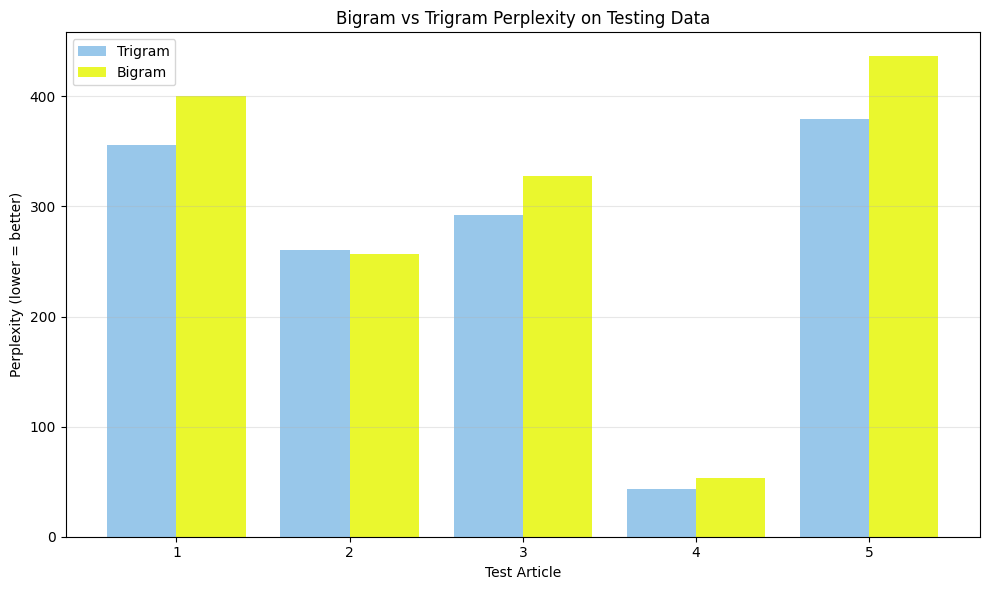

In [58]:
plt.figure(figsize=(10, 6))
x = np.arange(1, len(tri_ppl) + 1)
plt.bar(x - 0.2, tri_ppl, width=0.4, label='Trigram', color="#98c7ea")
plt.bar(x + 0.2, bi_ppl,  width=0.4, label='Bigram',  color="#eaf72e")
plt.xlabel('Test Article')
plt.ylabel('Perplexity (lower = better)')
plt.title('Bigram vs Trigram Perplexity on Testing Data')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.xticks(x)
plt.tight_layout()
plt.show()

C:\Users\ThinkPad T480s\AppData\Local\Temp\ipykernel_13144\3314236100.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([bi_ppl, tri_ppl], labels=['Bigram','Trigram'])


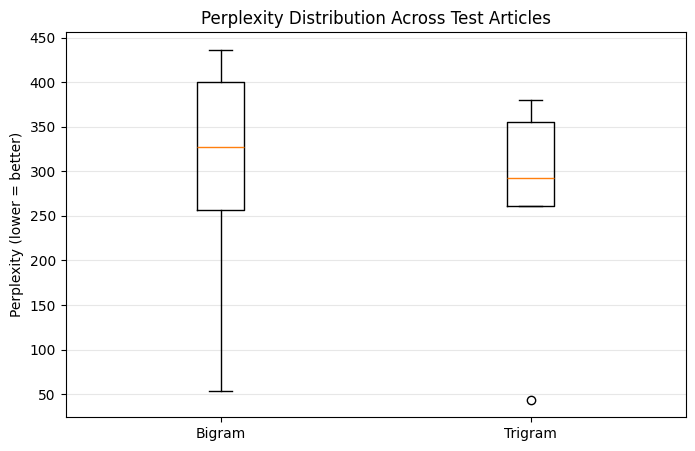

In [59]:
plt.figure(figsize=(8,5))
plt.boxplot([bi_ppl, tri_ppl], labels=['Bigram','Trigram'])
plt.ylabel('Perplexity (lower = better)')
plt.title('Perplexity Distribution Across Test Articles')
plt.grid(axis='y', alpha=0.3)
plt.show()


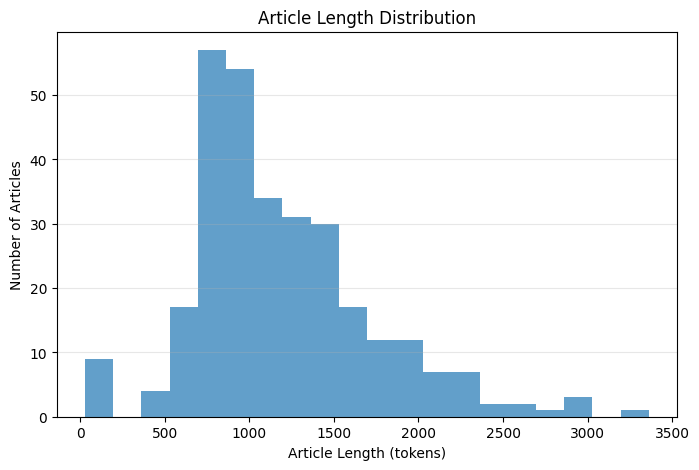

In [ ]:
article_lengths = [len(tokens) for tokens in df["lemmas"]]

plt.figure(figsize=(8,5))
plt.hist(article_lengths, bins=20, color="#35b41f", alpha=0.7)
plt.xlabel('Article Length (tokens)')
plt.ylabel('Number of Articles')
plt.title('Article Length Distribution')
plt.grid(axis='y', alpha=0.3)
plt.show()


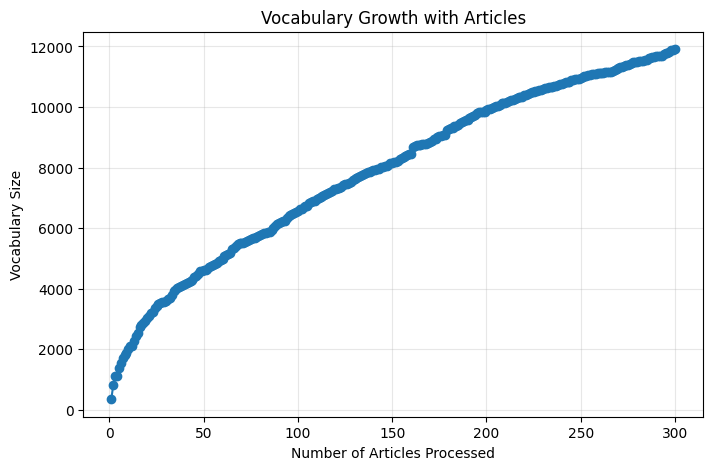

In [ ]:
vocab_growth = []
seen_vocab = set()
tokens_so_far = []

for tokens in df["lemmas"]:
    tokens_so_far.extend(tokens)
    seen_vocab.update(tokens_so_far)
    vocab_growth.append(len(seen_vocab))

plt.figure(figsize=(8,5))
plt.plot(range(1,len(vocab_growth)+1), vocab_growth, marker='o')
plt.xlabel('Number of Articles Processed')
plt.ylabel('Vocabulary Size')
plt.title('Vocabulary Growth with Articles')
plt.grid(alpha=0.3)
plt.show()


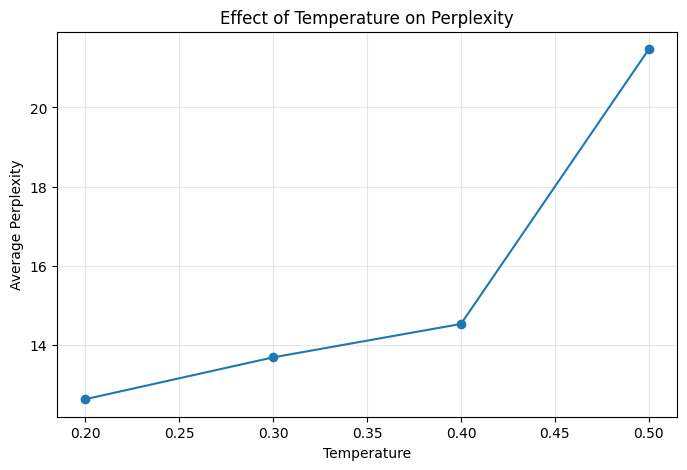

In [ ]:
temps = [0.2,0.3,0.4,0.5]
ppls = []

for t in temps:
    sample_articles = [generate_text(seeds[0], temperature=t, max_words=200) for _ in range(3)]
    pp = [calculate_perplexity(a) for a in sample_articles]
    ppls.append(np.mean(pp))

plt.figure(figsize=(8,5))
plt.plot(temps, ppls, marker='o')
plt.xlabel('Temperature')
plt.ylabel('Average Perplexity')
plt.title('Effect of Temperature on Perplexity')
plt.grid(alpha=0.3)
plt.show()
